## Objective
Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

Load Dataset

In [ ]:
sentiment_df=pd.read_csv('/content/fear_greed_index.csv')
trade_df=pd.read_csv('/content/historical_data.csv')

In [ ]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018


In [ ]:
trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
trade_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
sentiment_df.shape

(2644, 4)

In [ ]:
trade_df.shape

(211224, 16)

In [ ]:
sentiment_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
trade_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
sentiment_df.duplicated().sum()

np.int64(0)

In [ ]:
trade_df.duplicated().sum()

np.int64(0)

In [ ]:
trade_df = trade_df.drop_duplicates()
sentiment_df = sentiment_df.drop_duplicates()

## Data Preparation
- Converted timestamps to datetime
- Aligned both datasets at daily level

In [ ]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'],dayfirst=True).dt.date
sentiment_df['date']

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05
...,...
2639,2025-04-28
2640,2025-04-29
2641,2025-04-30
2642,2025-05-01


In [ ]:
sentiment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
trade_df['Timestamp IST'] = pd.to_datetime(trade_df['Timestamp IST'], dayfirst=True)
trade_df['date'] = trade_df['Timestamp IST'].dt.date

In [ ]:
trade_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [ ]:
trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


## Feature Engineering
Created key trading metrics at daily level

In [ ]:
# Daily PnL per trader
Daily_pnL=trade_df.groupby(['Account','date'])['Closed PnL'].sum().reset_index(name='daily_pnl')
Daily_pnL

,Account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [ ]:
# win rate
trade_df['win']= trade_df['Closed PnL']>0
win_rate=trade_df.groupby(['Account','date'])['win'].mean().reset_index(name='win_rate')
win_rate

,Account,date,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,0.390244
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,0.393023
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,0.441242
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,0.520000


In [ ]:
# average trade size
average_trade_size = trade_df.groupby(['Account', 'date'])['Size USD'].mean().reset_index(name='average_trade_size')
average_trade_size

,Account,date,average_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,17248.148148
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,2153.859390
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,1495.538419
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,1939.739989
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,1748.805333


In [ ]:
# number of trades per day
trades_per_day = trade_df.groupby(['Account', 'date']).size().reset_index(name='number_trades')
trades_per_day



,Account,date,number_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,82
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,430
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,902
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,75


In [ ]:
# long/short ratio
long_short = trade_df.groupby(['date', 'Side']).size().unstack().fillna(0)
long_short['long_short_ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))

long_short = long_short.reset_index()
long_short

Side,date,BUY,SELL,long_short_ratio
0,2023-05-01,3.0,0.0,inf
1,2023-12-05,7.0,2.0,3.500000
2,2023-12-14,5.0,6.0,0.833333
3,2023-12-15,2.0,0.0,inf
4,2023-12-16,3.0,0.0,inf
...,...,...,...,...
475,2025-04-27,209.0,128.0,1.632812
476,2025-04-28,652.0,727.0,0.896836
477,2025-04-29,1105.0,1138.0,0.971002
478,2025-04-30,838.0,275.0,3.047273


In [ ]:
actual_metrics = Daily_pnL.merge(win_rate, on=['Account', 'date'])
actual_metrics = actual_metrics.merge(average_trade_size, on=['Account', 'date'])
actual_metrics = actual_metrics.merge(trades_per_day, on=['Account', 'date'])

In [ ]:
actual_metrics = actual_metrics.merge(sentiment_df[['date', 'classification']],on='date',how='left')

In [ ]:
actual_metrics

,Account,date,daily_pnl,win_rate,average_trade_size,number_trades,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,5089.718249,177,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,0.000000,7976.664412,68,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,0.000000,23734.500000,40,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,0.000000,28186.666667,12,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,0.444444,17248.148148,27,Extreme Greed
...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,0.390244,2153.859390,82,Greed
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,0.393023,1495.538419,430,Neutral
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,0.441242,1939.739989,902,Greed
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,0.520000,1748.805333,75,Greed


In [ ]:
performance = actual_metrics.groupby('classification').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'}).reset_index()

performance

,classification,daily_pnl,win_rate
0,Extreme Fear,4619.439053,0.329659
1,Extreme Greed,5161.922644,0.386387
2,Fear,5328.818161,0.364033
3,Greed,3318.100730,0.343559
4,Neutral,3438.618818,0.355414


##Analysis

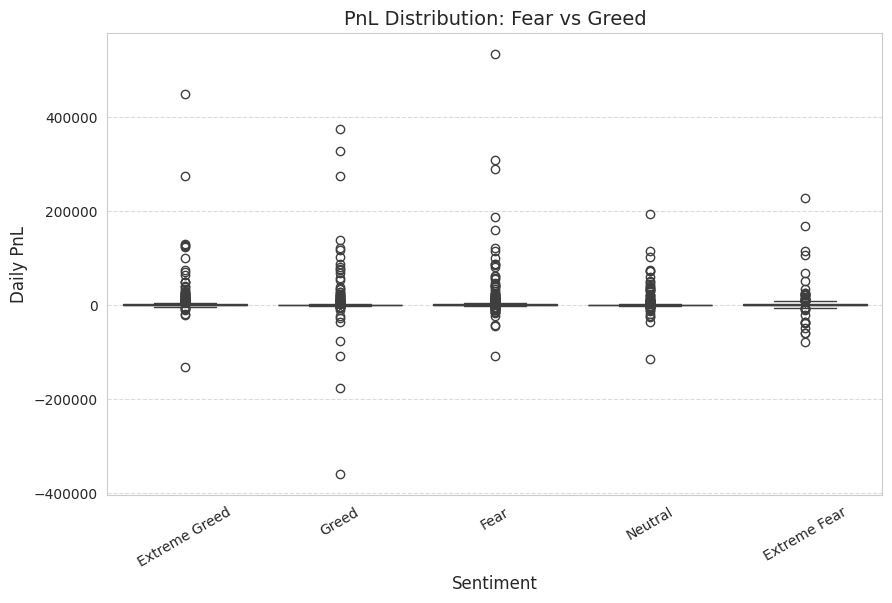

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='classification',
    y='daily_pnl',
    data=actual_metrics,

)

plt.title('PnL Distribution: Fear vs Greed', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Daily PnL', fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipykernel_2569/2112351770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


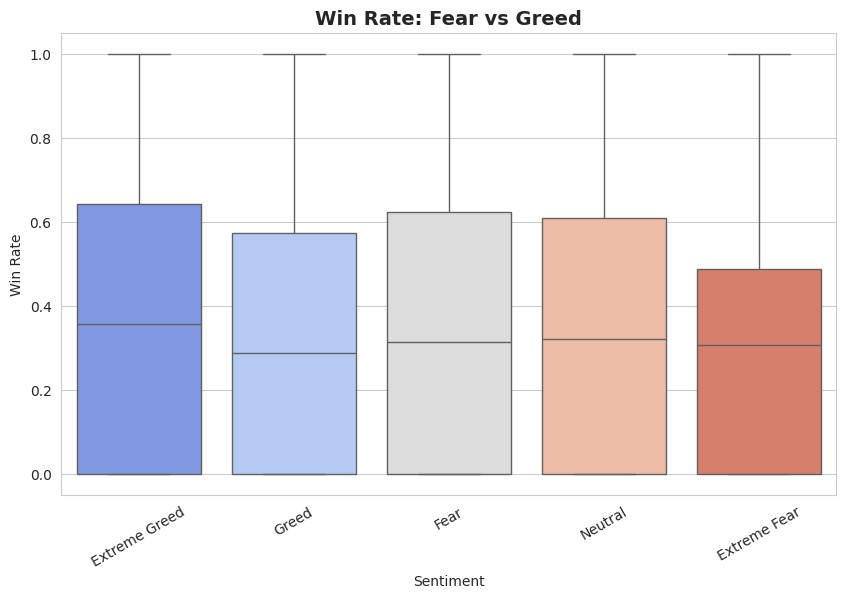

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    x='classification',
    y='win_rate',
    data=actual_metrics,
    palette='coolwarm'

)

plt.title('Win Rate: Fear vs Greed', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate')

plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_2569/1442934696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


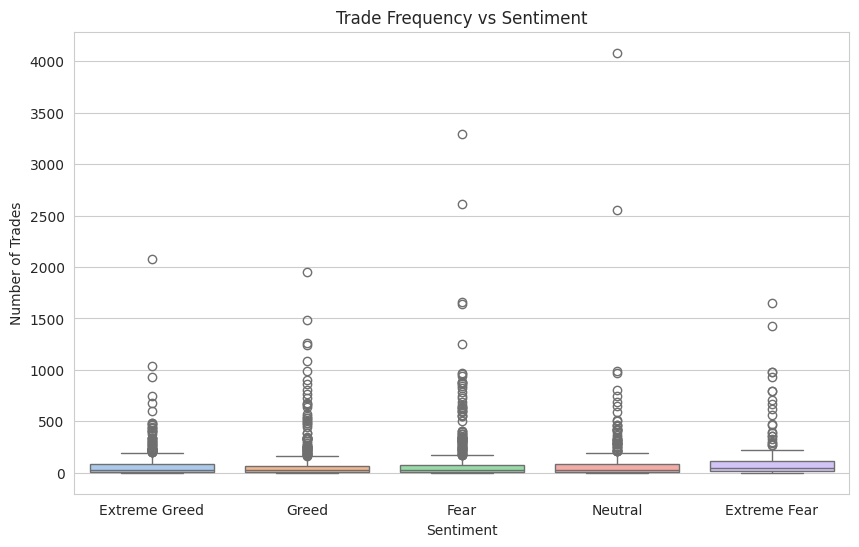

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='classification',
    y='number_trades',
    data=actual_metrics,
    palette='pastel'
)
plt.title('Trade Frequency vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')

plt.show()

/tmp/ipykernel_2569/2049643562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


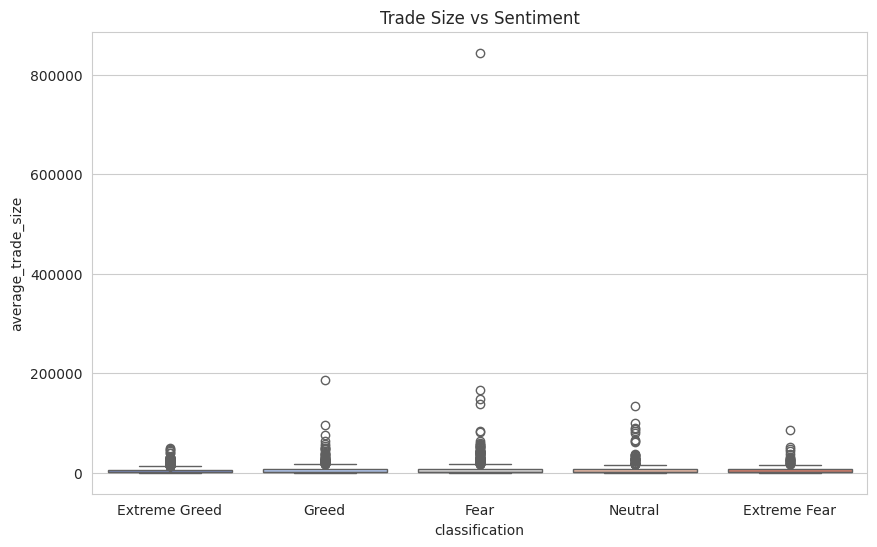

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='classification',
    y='average_trade_size',
    data=actual_metrics,
    palette='coolwarm'
)

plt.title('Trade Size vs Sentiment')
plt.show()

/tmp/ipykernel_2569/3182792577.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


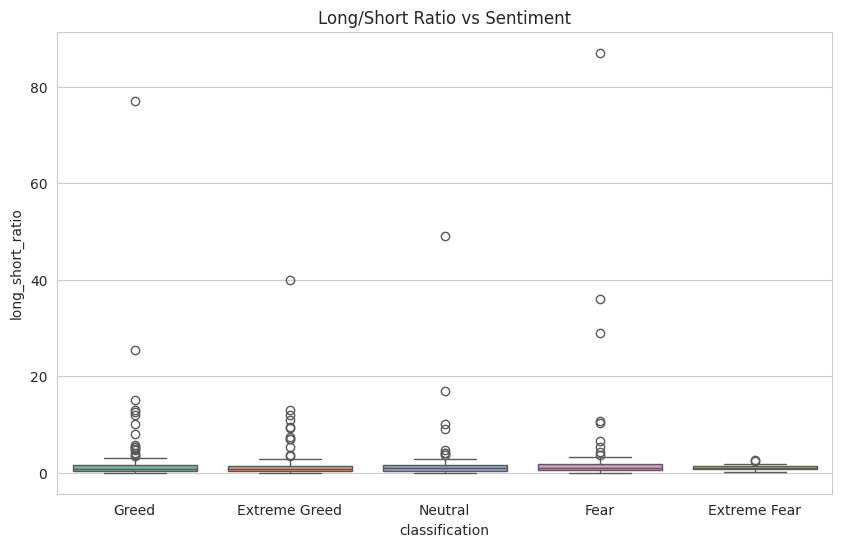

In [ ]:
long_short = long_short.merge(sentiment_df[['date', 'classification']],on='date',how='left')

plt.figure(figsize=(10,6))

sns.boxplot(
    x='classification',
    y='long_short_ratio',
    data=long_short,
    palette='Set2'
)

plt.title('Long/Short Ratio vs Sentiment')
plt.show()

## Segmentation

In [ ]:
median_size = actual_metrics['average_trade_size'].median()

actual_metrics['size_segment'] = actual_metrics['average_trade_size'].apply(
    lambda x: 'High Size' if x > median_size else 'Low Size'
)

In [ ]:
actual_metrics.groupby('size_segment')['daily_pnl'].mean().reset_index()

,size_segment,daily_pnl
0,High Size,6905.020233
1,Low Size,1894.180419


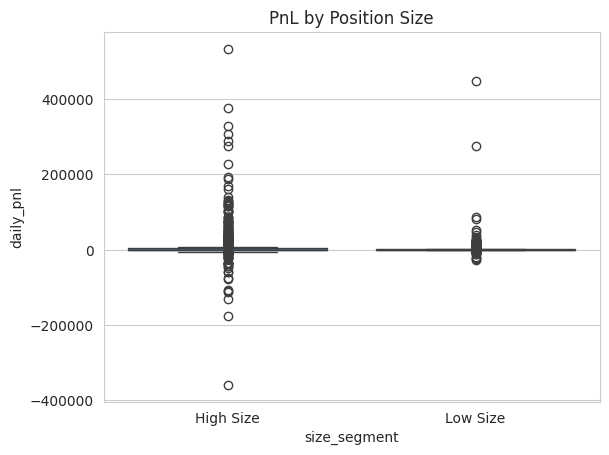

In [ ]:
sns.boxplot(
    x='size_segment',
    y='daily_pnl',
    data=actual_metrics
)
plt.title('PnL by Position Size')
plt.show()

In [ ]:
median_trade = actual_metrics['number_trades'].median()

actual_metrics['frequency'] = actual_metrics['number_trades'].apply(
    lambda x: 'High Frequency' if x > median_trade else 'Low Frequency'
)

In [ ]:
actual_metrics.groupby('frequency')['daily_pnl'].mean().reset_index()

,frequency,daily_pnl
0,High Frequency,7564.474676
1,Low Frequency,1256.835295


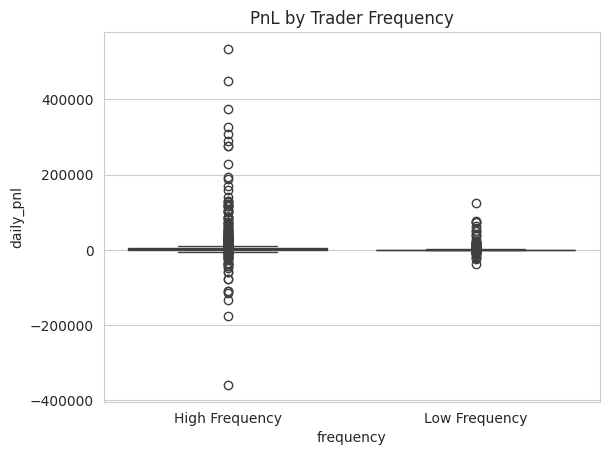

In [ ]:

sns.boxplot(
    x='frequency',
    y='daily_pnl',
    data=actual_metrics
)
plt.title('PnL by Trader Frequency')
plt.show()

In [ ]:
actual_metrics['consistency'] = actual_metrics['win_rate'].apply(
    lambda x: 'Consistent' if x > 0.6 else 'Inconsistent'
)

In [ ]:
actual_metrics.groupby('consistency')['daily_pnl'].mean().reset_index()

,consistency,daily_pnl
0,Consistent,12848.648971
1,Inconsistent,1518.907678


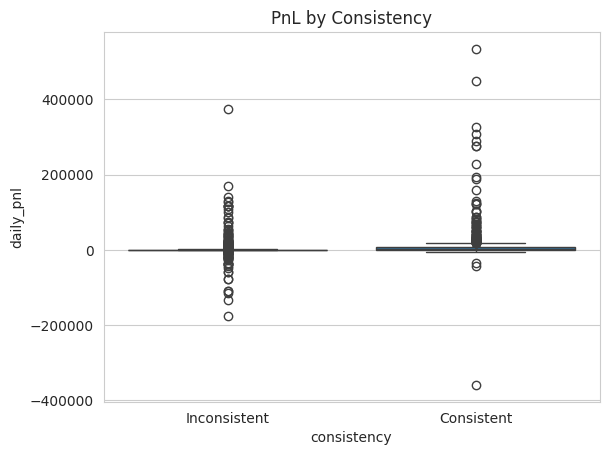

In [ ]:
sns.boxplot(
    x='consistency',
    y='daily_pnl',
    data=actual_metrics
)
plt.title('PnL by Consistency')
plt.show()

## Key Insights


##### 1.High vs Low Position Size Traders
Traders with larger position sizes,after analysis show higher difference in profit and loss(PnL), this is clearly indicate that risk increased. Where as, trader with smaller position sizes are indicates more stable and controlled performance.

---
##### 2.Frequent vs Infrequent Traders  
High-frequency traders usually earn less profit compared to low-frequency traders, which shows that overtrading may reduce performance. Traders who trade less often are more careful in choosing trades, which leads to relatively better outcomes.

---
##### 3.Consistent vs Inconsistent Traders  
Traders who have a higher win rates (consistent traders) , meaning they make more winning trades than losing ones, generally earn better profitability compare to inconsistent traders. This highlights that being consistent in trading is very important. The importance of maintaining consistency helps in reducing losses
and improving overall performance in the long run.



##Strategy Recommendation

#####1.Reduce risk during Fear day
During Fear days, traders must decrease their position size and avoid trading too frequently.In such market conditions, uncertainty and volatility are higher, which increase te chances of making losses. Taking fewer trades and using smaller amount per trade can managing in protecting capital.This strategy helps traders to avoid unnecessary losses and maintain stability until market conditions improve.

---

##### 2.Avoid overtrading during Greed periods
During Greed days, traders should control their trade frequency and limit the number of positions they take. ven though the market feels positive and confidence is high, sometimes this can lead to overconfidence and take immediate decisions. For instant decion , taking too many trades often decrise overall profit. Focus disciplined strategy and selective helps maintain better performance.

---

#####3.Focus on consistency over high activity  
Traders must be focus to maintain a higher win rate by following a disciplined strategy instead of increasing the number of trades. Consistent traders tend to perform better than those who trade frequently without a clear strategy.Following a clear and disciplined strategy usually leads to better results than trading frequently without proper planning.



## Summary

This analysis shows that trader performance and behavior are influenced by market sentiment. Fear periods are associated with lower performance and cautious behavior, while Greed periods lead to increased activity and risk-taking. Segmentation analysis highlights that consistent and low-frequency traders perform better. Based on these findings, disciplined and sentiment-aware strategies are recommended.